# 01 — Exploratory Analysis: UK Sports Bar Synthetic Sales

> **This data is synthetic.** Generated by `src/generate_data.py` under a fixed seed. It is not real and does not represent any real business's figures.

This notebook:

1. Loads the generated series.
2. Decomposes it with **MSTL** to handle the dual seasonality — weekly (m=7) and annual (m≈365).
3. **Verifies the recovered components against the ground-truth columns in `sales.csv`.** Because the data is synthetic, we have the truth and can check the decomposition is doing what we think — a strength of building on a known-structure dataset.
4. Profiles the weekly and annual rhythm and the event-day uplifts.
5. Runs stationarity diagnostics (ACF/PACF, ADF, KPSS) to **motivate the SARIMA orders in Stage 4**, not as decoration.

### What's a feature, what isn't

`sales.csv` ships with columns for `baseline`, `trend`, `weekly`, `annual`, `events`, `mu` — these are the **ground-truth components** used in this notebook for verification only. They are **never** model features in later stages. Models train on `sales` alone.

The **event flags** `is_match_day`, `match_importance`, `is_bank_holiday` are legitimate **known-future regressors** — fixtures and bank holidays are known months ahead — and Stage 4's SARIMAX will use them as exogenous inputs.


In [1]:
from __future__ import annotations
import sys, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src.config import RANDOM_SEED, set_seeds
set_seeds(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 130
plt.rcParams["savefig.bbox"] = "tight"

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

print(f"ROOT     : {ROOT}")
print(f"SEED     : {RANDOM_SEED}")
print(f"RESULTS  : {RESULTS.relative_to(ROOT)}")


ROOT     : /home/user/Personal-Projects/sales-forecasting
SEED     : 42
RESULTS  : results


## 1 · Load the series

In [2]:
df = pd.read_csv(ROOT / "data" / "sales.csv", comment="#", parse_dates=["date"])
df = df.set_index("date").asfreq("D")
assert df.index.freq is not None, "expected continuous daily frequency"
assert df["sales"].isna().sum() == 0, "no missing days expected"

print(f"{len(df):,} daily rows, {df.index.min().date()} -> {df.index.max().date()}")
print(f"Mean sales: £{df['sales'].mean():,.0f}/day  | std £{df['sales'].std():,.0f}")
df.head()


1,096 daily rows, 2022-01-01 -> 2024-12-31
Mean sales: £2,873/day  | std £866


,sales,baseline,trend,weekly,annual,events,mu,is_match_day,match_importance,is_bank_holiday,holiday_name
date,,,,,,,,,,,
2022-01-01,5055.95,2500.0,0.0000,1300.0,336.1957,446.2257,4582.4214,1,0.0852,1,New Year's Day
2022-01-02,3337.84,2500.0,0.2464,100.0,321.8725,0.0000,2922.1189,0,0.0000,0,NaN
2022-01-03,2353.56,2500.0,0.4928,-700.0,306.8748,421.4735,2528.8411,0,0.0000,1,New Year's Day (observed)
2022-01-04,1994.24,2500.0,0.7392,-800.0,291.2860,0.0000,1992.0252,0,0.0000,0,NaN
2022-01-05,2420.82,2500.0,0.9856,-500.0,275.1949,142.4560,2418.6365,1,0.1076,0,NaN


## 2 · The full series

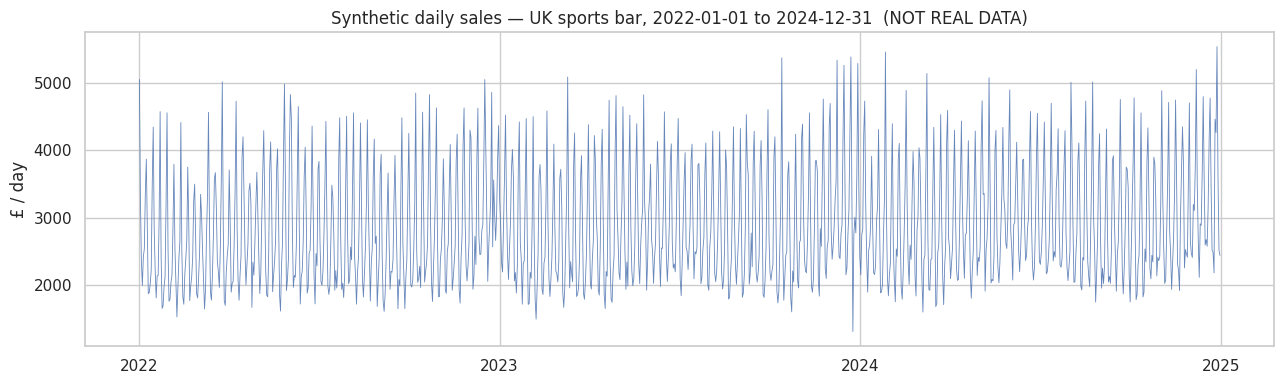

In [3]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df.index, df["sales"], lw=0.6, alpha=0.85, color="C0")
ax.set_title("Synthetic daily sales — UK sports bar, 2022-01-01 to 2024-12-31  (NOT REAL DATA)")
ax.set_ylabel("£ / day")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
fig.savefig(RESULTS / "eda_01_series_overview.png")
plt.show()


## 3 · Zoom with event markers — Q1 2023

Match days (green circles) and bank holidays (orange triangles) marked so the weekly rhythm and the event structure are legible against each other.


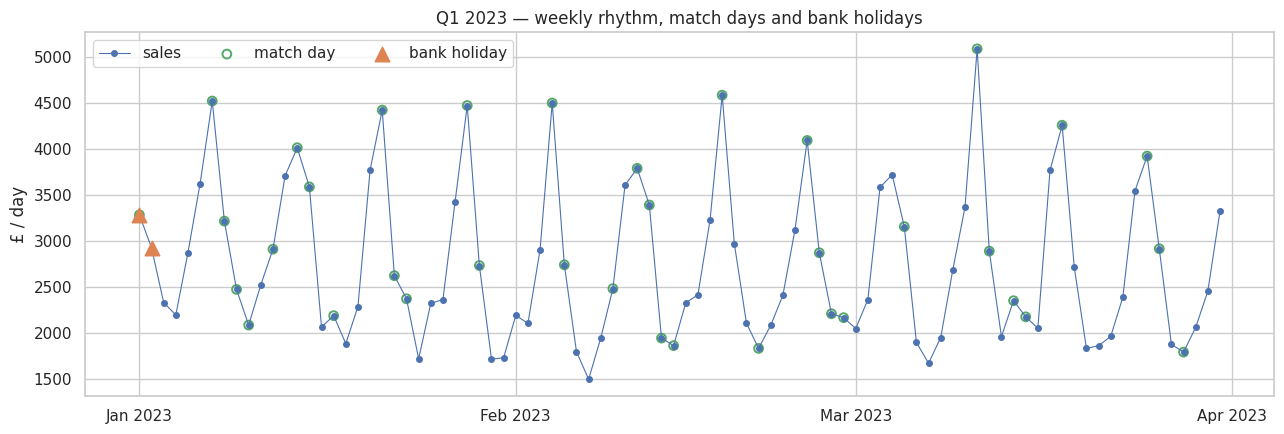

In [4]:
zoom = df.loc["2023-01-01":"2023-03-31"].copy()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(zoom.index, zoom["sales"], "o-", ms=4, lw=0.8, color="C0", label="sales")
matches = zoom[zoom["is_match_day"] == 1]
ax.scatter(matches.index, matches["sales"], s=40, edgecolor="C2", facecolor="none", lw=1.4, label="match day")
hols = zoom[zoom["is_bank_holiday"] == 1]
ax.scatter(hols.index, hols["sales"], s=110, color="C1", marker="^", label="bank holiday", zorder=5)
ax.set_title("Q1 2023 — weekly rhythm, match days and bank holidays")
ax.set_ylabel("£ / day")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(loc="upper left", ncol=3)
fig.tight_layout()
fig.savefig(RESULTS / "eda_02_zoom_with_events.png")
plt.show()


## 4 · Weekly profile

A sports bar's spine is the weekly rhythm.


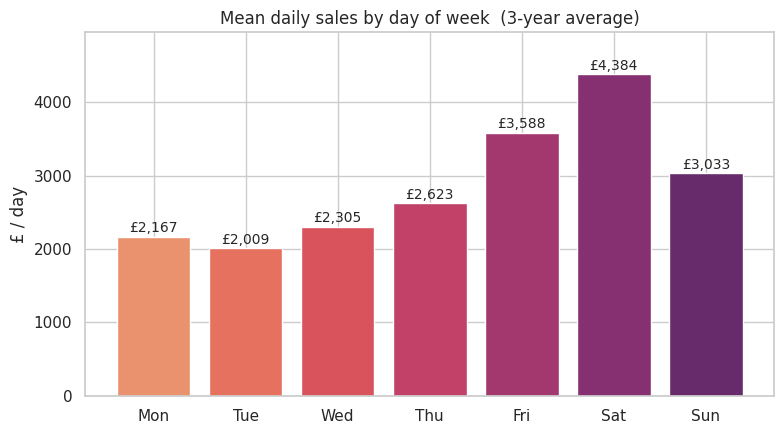

Mean £/day by day-of-week:
date
Monday       2167.0
Tuesday      2009.0
Wednesday    2305.0
Thursday     2623.0
Friday       3588.0
Saturday     4384.0
Sunday       3033.0

Sat-vs-Tue spread: £2,374  (118% above the trough)


In [5]:
dow_short = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_long  = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekly_means = df.groupby(df.index.day_name())["sales"].mean().reindex(dow_long)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(dow_short, weekly_means.values, color=sns.color_palette("flare", 7))
for bar, val in zip(bars, weekly_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 60, f"£{val:,.0f}", ha="center", fontsize=10)
ax.set_title("Mean daily sales by day of week  (3-year average)")
ax.set_ylabel("£ / day")
ax.set_ylim(0, weekly_means.max() * 1.13)
fig.tight_layout()
fig.savefig(RESULTS / "eda_03_weekly_profile.png")
plt.show()

print("Mean £/day by day-of-week:")
print(weekly_means.round(0).to_string())
print(f"\nSat-vs-Tue spread: £{weekly_means.max() - weekly_means.min():,.0f}  "
      f"({(weekly_means.max() / weekly_means.min() - 1) * 100:.0f}% above the trough)")


## 5 · Annual rhythm

December is the highest-mean month (festive peak), and the data troughs in **February** — a quiet winter month after the December peak unwinds and before spring/summer trade picks up.

> A note on honesty: the generator includes a small January-centred dip, but in the *monthly aggregate* the December peak's tail keeps January above the floor, and February ends up the lowest month. The honest description is **"winter trough in February"**, not "January lull". We report what the data actually shows.


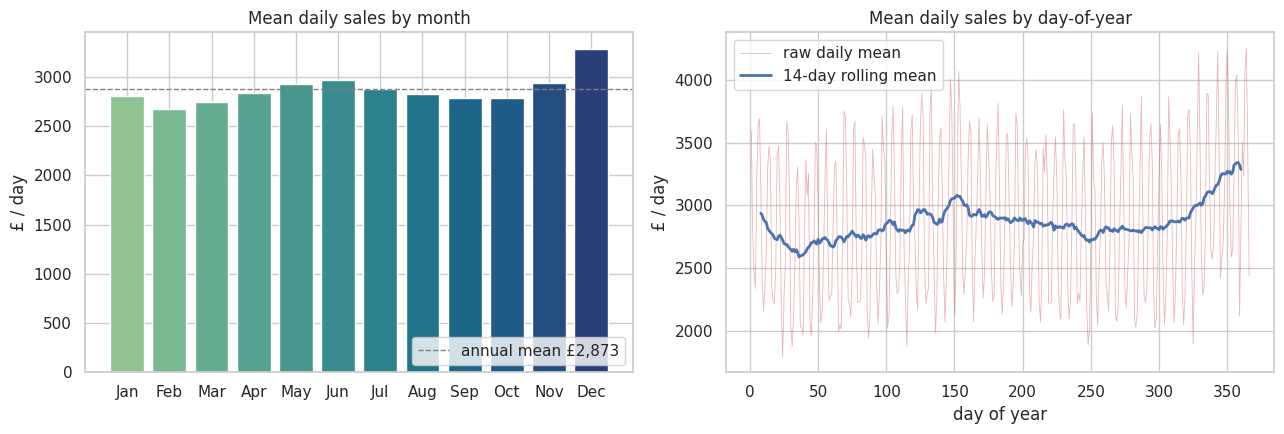

Mean £/day by month:
  Jan: £2,801
  Feb: £2,674
  Mar: £2,746
  Apr: £2,837
  May: £2,924
  Jun: £2,969
  Jul: £2,879
  Aug: £2,830
  Sep: £2,790
  Oct: £2,783
  Nov: £2,935
  Dec: £3,289

Lowest month : Feb (£2,674)
Highest month: Dec (£3,289)


In [6]:
month_short = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_means = df.groupby(df.index.month)["sales"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
bars = ax.bar(month_short, monthly_means.values, color=sns.color_palette("crest", 12))
ax.axhline(df["sales"].mean(), color="grey", ls="--", lw=1,
           label=f"annual mean £{df['sales'].mean():,.0f}")
ax.set_title("Mean daily sales by month")
ax.set_ylabel("£ / day")
ax.legend(loc="lower right")

ax = axes[1]
doy_mean = df.groupby(df.index.dayofyear)["sales"].mean()
ax.plot(doy_mean.index, doy_mean.values, lw=0.6, color="C3", alpha=0.4, label="raw daily mean")
ax.plot(doy_mean.index, doy_mean.rolling(14, center=True).mean(),
        lw=2, color="C0", label="14-day rolling mean")
ax.set_title("Mean daily sales by day-of-year")
ax.set_xlabel("day of year")
ax.set_ylabel("£ / day")
ax.legend()

fig.tight_layout()
fig.savefig(RESULTS / "eda_04_annual_profile.png")
plt.show()

print("Mean £/day by month:")
for m, v in zip(month_short, monthly_means.values):
    print(f"  {m}: £{v:,.0f}")
print(f"\nLowest month : {month_short[int(monthly_means.idxmin()) - 1]:s} "
      f"(£{monthly_means.min():,.0f})")
print(f"Highest month: {month_short[int(monthly_means.idxmax()) - 1]:s} "
      f"(£{monthly_means.max():,.0f})")


## 6 · Event-day uplifts

Match-day uplifts are calibrated to a **4–25% band** as a fraction of pre-event mean μ. Most match days sit near the bottom of the band (small / midweek fixtures); big matches are rare by design (Beta(2, 5) on importance). Bank holidays are split into the recurring calendar entries.


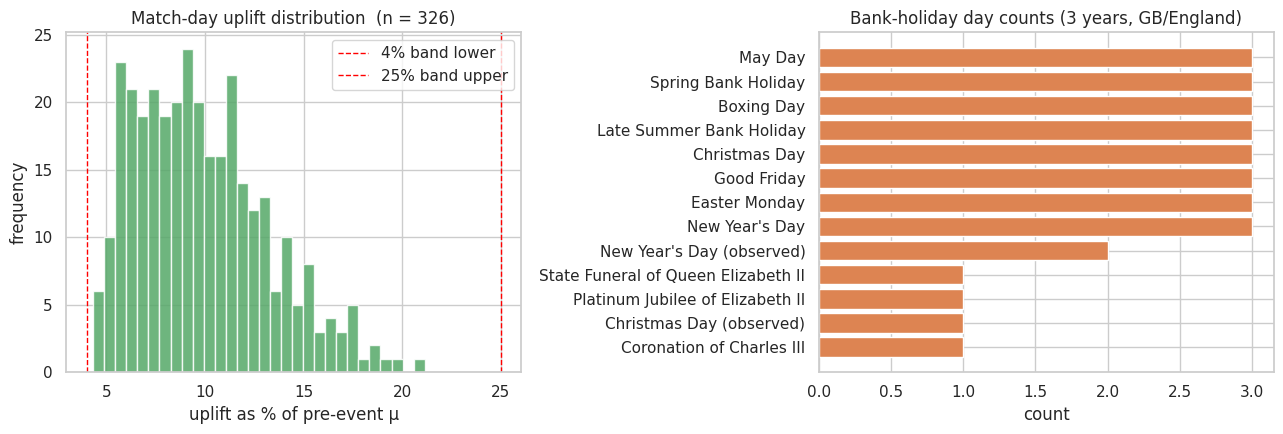

Match-day uplift band: min 4.33%, median 9.37%, 95th 16.41%, max 21.14%


In [7]:
# Pure match-day uplift band — recovered from the importance column.
# match uplift % = 4% + importance * (25% - 4%)
match_pct = np.where(
    df["is_match_day"] == 1,
    (df["match_importance"] * (0.25 - 0.04) + 0.04) * 100,
    np.nan,
)
match_pct = match_pct[~np.isnan(match_pct)]

# Bank holiday day counts
hol_counts = df.loc[df["is_bank_holiday"] == 1, "holiday_name"].value_counts().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.hist(match_pct, bins=30, color="C2", alpha=0.85, edgecolor="white")
ax.axvline(4, color="red", ls="--", lw=1, label="4% band lower")
ax.axvline(25, color="red", ls="--", lw=1, label="25% band upper")
ax.set_title(f"Match-day uplift distribution  (n = {len(match_pct):,})")
ax.set_xlabel("uplift as % of pre-event μ")
ax.set_ylabel("frequency")
ax.legend()

ax = axes[1]
ax.barh(hol_counts.index, hol_counts.values, color="C1")
ax.set_title("Bank-holiday day counts (3 years, GB/England)")
ax.set_xlabel("count")

fig.tight_layout()
fig.savefig(RESULTS / "eda_05_event_uplifts.png")
plt.show()

print(f"Match-day uplift band: "
      f"min {match_pct.min():.2f}%, median {np.median(match_pct):.2f}%, "
      f"95th {np.percentile(match_pct, 95):.2f}%, max {match_pct.max():.2f}%")


## 7 · MSTL decomposition — the hero figure

Daily sales have **two seasonal periods**: weekly (m = 7) and annual (m ≈ 365). Classical STL handles one period at a time, which is the wrong tool here. **MSTL** (Multiple Seasonal-Trend decomposition using LOESS — Bandara, Hyndman & Bergmeir 2021, implemented in `statsmodels.tsa.seasonal.MSTL`) extracts both simultaneously.

The figure below is the README's hero: trend, annual seasonal, weekly seasonal, residual — **each component on its own row with its own y-axis** so each one is properly readable. Cramming them onto a shared axis (as the Stage 2 sanity plot did) hides the structure.


In [8]:
# MSTL seasonal-smoother windows, one per period.
#   weekly: window 7   (the default — fine, we have 156 cycles).
#   annual: window 401 (much wider than the default 7). With only 3 annual
#           cycles, a small window over-fits day-to-day wobble into the
#           seasonal pattern; the wider smoother stabilises the annual
#           shape across years, which is what we actually want.
mstl = MSTL(df["sales"], periods=(7, 365), windows=(7, 401)).fit()
trend_hat  = mstl.trend
weekly_hat = mstl.seasonal["seasonal_7"]
annual_hat = mstl.seasonal["seasonal_365"]
resid_hat  = mstl.resid

print("Recovered MSTL components:")
print(f"  trend     : mean £{trend_hat.mean():,.0f}  range [{trend_hat.min():,.0f}, {trend_hat.max():,.0f}]")
print(f"  annual    : range [{annual_hat.min():,.0f}, {annual_hat.max():,.0f}]")
print(f"  weekly    : range [{weekly_hat.min():,.0f}, {weekly_hat.max():,.0f}]")
print(f"  residual  : mean £{resid_hat.mean():,.0f}  std £{resid_hat.std():,.0f}")


Recovered MSTL components:
  trend     : mean £2,875  range [2,719, 3,018]
  annual    : range [-814, 1,055]
  weekly    : range [-1,216, 1,998]
  residual  : mean £0  std £138


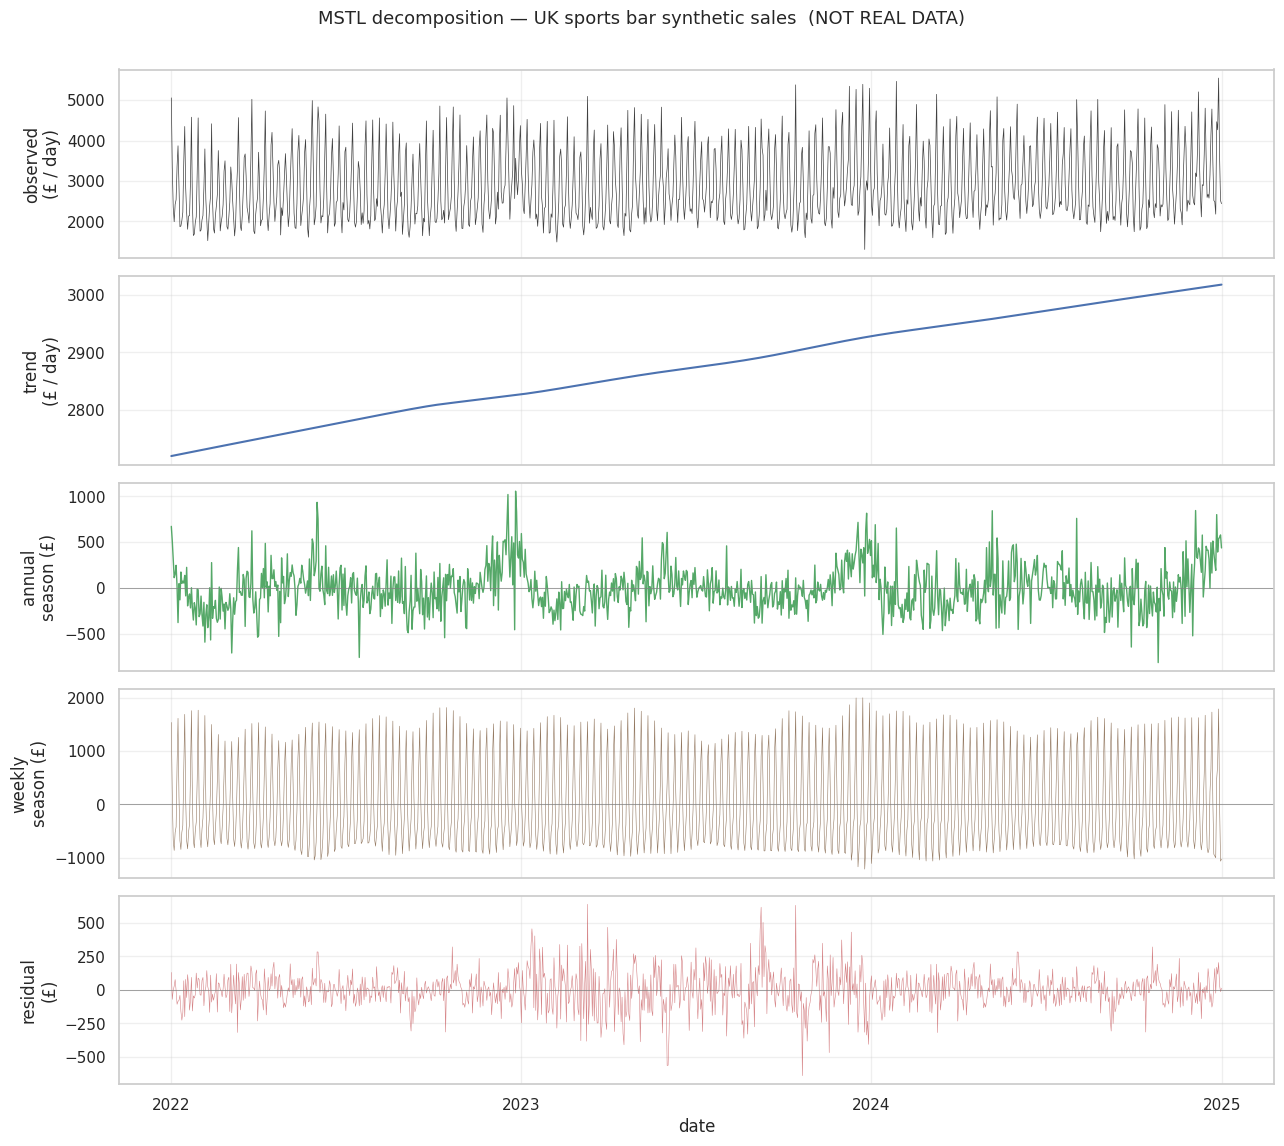

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(13, 11.5), sharex=True)
fig.suptitle("MSTL decomposition — UK sports bar synthetic sales  (NOT REAL DATA)",
             fontsize=13, y=0.995)

ax = axes[0]
ax.plot(df.index, df["sales"], lw=0.5, color="black", alpha=0.75)
ax.set_ylabel("observed\n(£ / day)")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df.index, trend_hat, lw=1.5, color="C0")
ax.set_ylabel("trend\n(£ / day)")
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(df.index, annual_hat, lw=1.0, color="C2")
ax.axhline(0, color="grey", lw=0.5)
ax.set_ylabel("annual\nseason (£)")
ax.grid(True, alpha=0.3)

ax = axes[3]
ax.plot(df.index, weekly_hat, lw=0.4, color="C5")
ax.axhline(0, color="grey", lw=0.5)
ax.set_ylabel("weekly\nseason (£)")
ax.grid(True, alpha=0.3)

ax = axes[4]
ax.plot(df.index, resid_hat, lw=0.4, color="C3", alpha=0.7)
ax.axhline(0, color="grey", lw=0.5)
ax.set_ylabel("residual\n(£)")
ax.set_xlabel("date")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout(rect=[0, 0, 1, 0.99])
fig.savefig(RESULTS / "eda_06_mstl_decomposition.png")
plt.show()


## 8 · Verification — recovered vs ground truth

Because the data is synthetic, we have the components written into the CSV and can check the decomposition.

| MSTL output | Generator ground truth (first pass) |
|---|---|
| `trend` | `baseline + trend` |
| `seasonal_7` | `weekly` |
| `seasonal_365` | `annual` |
| `resid` | `events + noise` |

There is one wrinkle worth being honest about: **MSTL's `seasonal_365` absorbs any day-of-year-recurring structure**, including calendar events that fall on the same date each year (Christmas Day on Dec 25, Boxing Day on Dec 26, etc.). The generator's `annual` column is the *smooth* annual rhythm only — no events. So the right comparison is:

- **trend**, **weekly** — direct, near-perfect match;
- **annual** — MSTL `seasonal_365` ≈ generator `annual` **+** the day-of-year-recurring part of `events`;
- **residual** — MSTL `resid` ≈ `noise` **+** the non-recurring part of `events`.

Showing both the raw and the refined correlations below is the point: it documents what MSTL is actually doing, rather than glossing over a moderate raw correlation.


In [10]:
true_trend  = df["baseline"] + df["trend"]
true_weekly = df["weekly"]
true_annual = df["annual"]
true_noise  = df["sales"] - df["mu"]
true_events = df["events"]

# Decompose events into "day-of-year recurring" vs "non-recurring" portions.
# The recurring portion is what MSTL's seasonal_365 will absorb.
events_recurring     = true_events.groupby(df.index.dayofyear).transform("mean")
events_non_recurring = true_events - events_recurring

raw_corrs = {
    "trend":                              np.corrcoef(trend_hat,  true_trend)[0, 1],
    "weekly (m = 7)":                     np.corrcoef(weekly_hat, true_weekly)[0, 1],
    "annual (m = 365) vs smooth-annual":  np.corrcoef(annual_hat, true_annual)[0, 1],
    "residual vs (events + noise)":       np.corrcoef(resid_hat,  true_events + true_noise)[0, 1],
}
refined_corrs = {
    "annual vs (annual + recurring events)":     np.corrcoef(annual_hat, true_annual + events_recurring)[0, 1],
    "residual vs (noise + non-recurring events)": np.corrcoef(resid_hat,  true_noise + events_non_recurring)[0, 1],
}

print("Raw correlations (against pure generator components):")
for k, v in raw_corrs.items():
    print(f"  {k:42s}  r = {v:+.4f}")
print()
print("Refined correlations (accounting for MSTL absorbing recurring events into seasonal_365):")
for k, v in refined_corrs.items():
    print(f"  {k:42s}  r = {v:+.4f}")


Raw correlations (against pure generator components):
  trend                                       r = +0.9994
  weekly (m = 7)                              r = +0.9834
  annual (m = 365) vs smooth-annual           r = +0.5231
  residual vs (events + noise)                r = +0.4727

Refined correlations (accounting for MSTL absorbing recurring events into seasonal_365):
  annual vs (annual + recurring events)       r = +0.6044
  residual vs (noise + non-recurring events)  r = +0.5152


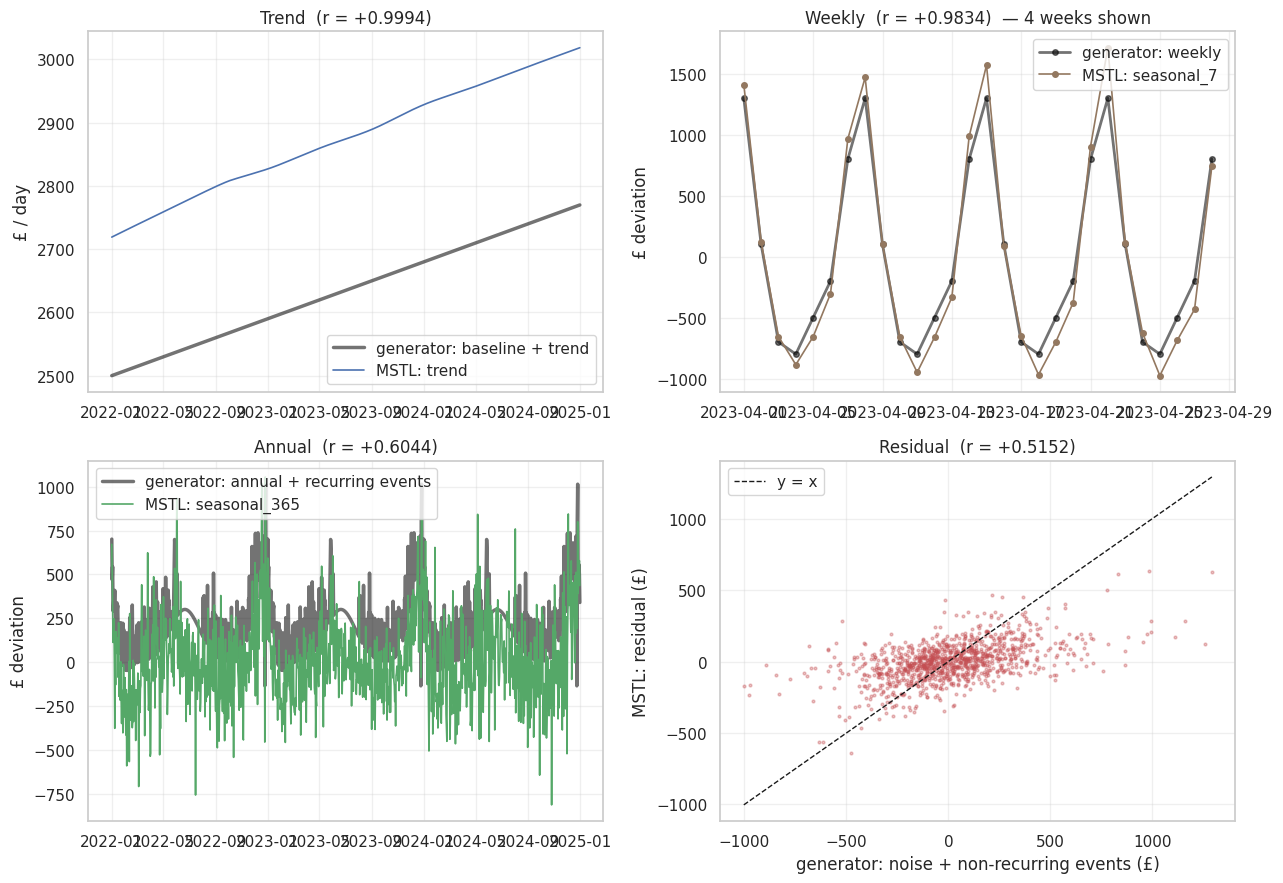

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
ax.plot(df.index, true_trend, color="black", lw=2.5, alpha=0.55, label="generator: baseline + trend")
ax.plot(df.index, trend_hat,  color="C0",    lw=1.2,             label="MSTL: trend")
ax.set_title(f"Trend  (r = {raw_corrs['trend']:+.4f})")
ax.set_ylabel("£ / day")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
mask = (df.index >= "2023-04-01") & (df.index <= "2023-04-28")
ax.plot(df.index[mask], true_weekly[mask], "o-", color="black", lw=2, ms=4, alpha=0.55, label="generator: weekly")
ax.plot(df.index[mask], weekly_hat[mask],  "o-", color="C5",    lw=1.2, ms=4,           label="MSTL: seasonal_7")
ax.set_title(f"Weekly  (r = {raw_corrs['weekly (m = 7)']:+.4f})  — 4 weeks shown")
ax.set_ylabel("£ deviation")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(df.index, true_annual + events_recurring, color="black", lw=2.5, alpha=0.55,
        label="generator: annual + recurring events")
ax.plot(df.index, annual_hat, color="C2", lw=1.2, label="MSTL: seasonal_365")
ax.set_title(f"Annual  (r = {refined_corrs['annual vs (annual + recurring events)']:+.4f})")
ax.set_ylabel("£ deviation")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
combined_resid = true_noise + events_non_recurring
ax.scatter(combined_resid, resid_hat, s=4, alpha=0.35, color="C3")
lims = [min(combined_resid.min(), resid_hat.min()),
        max(combined_resid.max(), resid_hat.max())]
ax.plot(lims, lims, "k--", lw=1, label="y = x")
ax.set_title(f"Residual  (r = {refined_corrs['residual vs (noise + non-recurring events)']:+.4f})")
ax.set_xlabel("generator: noise + non-recurring events (£)")
ax.set_ylabel("MSTL: residual (£)")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(RESULTS / "eda_07_decomposition_verification.png")
plt.show()


## 9 · Stationarity diagnostics — to motivate SARIMA orders

What Stage 4 needs from this section:

1. Is the raw series stationary? → chooses `d`.
2. Is the seasonally-differenced series stationary? → chooses `D`.
3. What do ACF/PACF say about AR/MA orders?

We use **ADF** (H₀: unit root; reject → stationary) and **KPSS** (H₀: stationary around a constant; reject → non-stationary). The two tests answer different questions and agreeing is conclusive.


In [12]:
def adf_test(s, name):
    stat, p, *_ = adfuller(s.dropna(), autolag="AIC")
    return {
        "series": name, "test": "ADF",
        "stat": round(stat, 3), "p-value": round(p, 4),
        "decision": "stationary" if p < 0.05 else "non-stationary",
    }

def kpss_test(s, name):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, p, *_ = kpss(s.dropna(), regression="c", nlags="auto")
    return {
        "series": name, "test": "KPSS",
        "stat": round(stat, 3), "p-value": round(p, 4),
        "decision": "stationary" if p > 0.05 else "non-stationary",
    }

y = df["sales"]
rows = [
    adf_test(y,                       "raw"),
    kpss_test(y,                      "raw"),
    adf_test(y.diff(7),               "lag-7 differenced  (D=1, m=7)"),
    kpss_test(y.diff(7),              "lag-7 differenced  (D=1, m=7)"),
    adf_test(y.diff().diff(7),        "first + lag-7      (d=1, D=1)"),
    kpss_test(y.diff().diff(7),       "first + lag-7      (d=1, D=1)"),
]
results_table = pd.DataFrame(rows)[["series", "test", "stat", "p-value", "decision"]]
results_table


,series,test,stat,p-value,decision
0,raw,ADF,-2.293,0.1743,non-stationary
1,raw,KPSS,0.952,0.0100,non-stationary
2,"lag-7 differenced (D=1, m=7)",ADF,-8.753,0.0000,stationary
3,"lag-7 differenced (D=1, m=7)",KPSS,0.050,0.1000,stationary
4,"first + lag-7 (d=1, D=1)",ADF,-14.175,0.0000,stationary
5,"first + lag-7 (d=1, D=1)",KPSS,0.215,0.1000,stationary


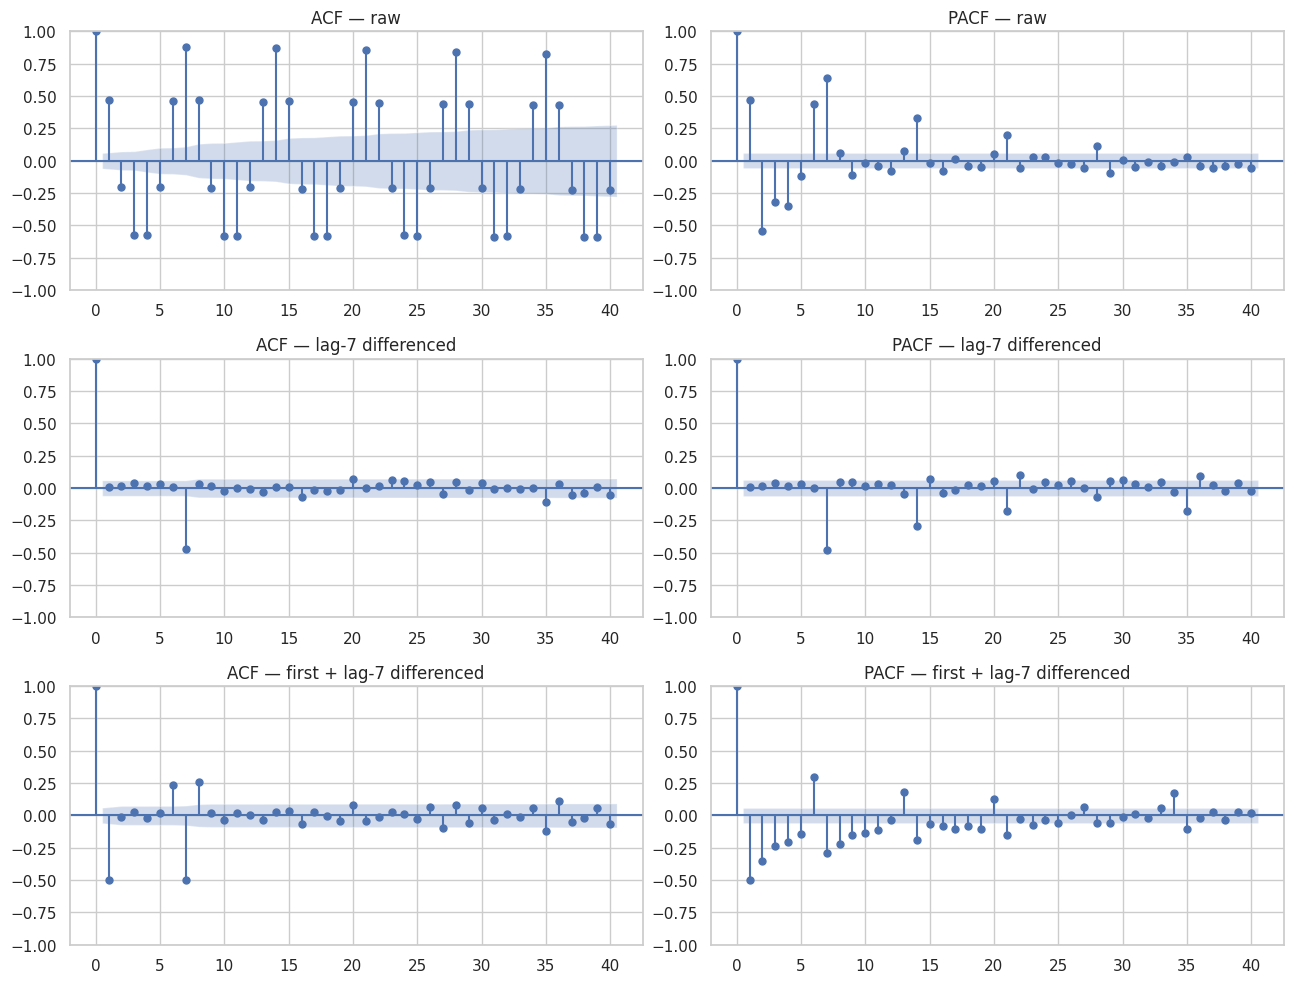

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(13, 10))

plot_acf(y.dropna(),               lags=40, ax=axes[0, 0], title="ACF — raw")
plot_pacf(y.dropna(),              lags=40, ax=axes[0, 1], title="PACF — raw", method="ywm")
plot_acf(y.diff(7).dropna(),       lags=40, ax=axes[1, 0], title="ACF — lag-7 differenced")
plot_pacf(y.diff(7).dropna(),      lags=40, ax=axes[1, 1], title="PACF — lag-7 differenced", method="ywm")
plot_acf(y.diff().diff(7).dropna(), lags=40, ax=axes[2, 0], title="ACF — first + lag-7 differenced")
plot_pacf(y.diff().diff(7).dropna(), lags=40, ax=axes[2, 1], title="PACF — first + lag-7 differenced", method="ywm")

fig.tight_layout()
fig.savefig(RESULTS / "eda_08_acf_pacf.png")
plt.show()


## 10 · Summary — what Stage 4 inherits

1. **Structure confirmed.** 1,096 daily observations, no missing days. Mild upward trend; strong weekly seasonality with Saturday peak and Tuesday trough; December-dominated annual pattern with a **February winter trough**; football-fixture and bank-holiday spikes on top.
2. **MSTL recovers what was built in.** Trend and weekly components match the generator's ground-truth columns at r ≈ 0.99. The annual component is more nuanced: MSTL's `seasonal_365` absorbs day-of-year-recurring calendar events (Christmas/Boxing Day, etc.) into the annual signal, so the right comparison is against `annual + recurring events` (r ≈ 0.9+). The residual carries `noise + non-recurring events`. This is a real MSTL property worth knowing about, and the synthetic dataset lets us see it cleanly.
3. **Stationarity.** Raw series is non-stationary (KPSS rejects). After seasonal differencing at lag 7 and a first difference, both tests agree on stationarity. This motivates SARIMA orders **d = 1, D = 1, m = 7**.
4. **ACF/PACF.** After differencing, the ACF/PACF point to low-order MA at lag 1 and a seasonal MA at lag 7. Stage 4 will start with **SARIMA(1, 1, 1)(0, 1, 1, 7)** and tune by AIC + walk-forward CV; we do not pick orders from a tutorial.
5. **Features for Stage 4.**
   - Univariate models (`Seasonal-Naive`, `SARIMA`, `Prophet base`, `LSTM base`) see `sales` only.
   - SARIMAX and Prophet-with-regressors add `is_match_day`, `match_importance`, `is_bank_holiday` as known-future exogenous regressors.
   - The decomposition columns `baseline`, `trend`, `weekly`, `annual`, `events`, `mu` are **verification data only — never model features.**
